## 3. Regression

In this task, we apply regression models to predict future healthcare demands based on COVID-19 trends. Specifically, we aim to forecast the number of ICU patients using variables such as new cases, deaths, and hospitalization metrics.

This type of analysis supports proactive healthcare planning by estimating critical care needs ahead of time. We evaluate our regression model's performance using metrics such as Mean Squared Error (MSE) and R-squared (R²), and interpret which predictors contribute most to ICU load.


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor


In [ ]:
df = pd.read_csv("owid_covid_data_us_subset.csv")

# Convert date column
df['date'] = pd.to_datetime(df['date'])

# Fill and drop NAs for the icu-related analysis
df.ffill(inplace=True)
df.dropna(subset=[
    'daily_case_change_rate', 'daily_death_change_rate',
    '7day_avg_new_cases', '7day_avg_new_deaths',
    'hosp_patients', 'icu_patients'
], inplace=True)

df.head()


,date,total_cases,new_cases,total_deaths,new_deaths,total_cases_per_million,total_deaths_per_million,icu_patients,hosp_patients,weekly_hosp_admissions,daily_case_change_rate,daily_death_change_rate,hospitalization_rate,icu_rate,case_fatality_rate,7day_avg_new_cases,7day_avg_new_deaths,hospitalization_need,icu_requirement
6,2020-07-27,4255512.0,61596.0,152738.0,1148.0,12579.484,451.500,14230.0,47165.0,34623.0,1.468699,0.757306,1.108327,0.334390,3.589180,66024.714286,1124.142857,High,High
7,2020-07-28,4313271.0,57759.0,153689.0,951.0,12750.223,454.312,14578.0,48115.0,35638.0,1.357275,0.622635,1.115511,0.337980,3.563166,65702.857143,1126.857143,High,High
8,2020-07-29,4367278.0,54007.0,154625.0,936.0,12909.870,457.078,14021.0,45617.0,36275.0,1.252112,0.609022,1.044518,0.321047,3.540535,65058.285714,1136.714286,High,High
9,2020-07-30,4425986.0,58708.0,155788.0,1163.0,13083.413,460.516,14653.0,46832.0,36799.0,1.344270,0.752142,1.058115,0.331067,3.519848,64397.142857,1132.428571,High,High
10,2020-07-31,4490841.0,64855.0,156967.0,1179.0,13275.128,464.001,14603.0,46150.0,38019.0,1.465323,0.756798,1.027647,0.325173,3.495270,63317.000000,1130.714286,High,High


### Scale Features, Split Data, and Training the Linear Regression Model

In [4]:
# Define response and predictor variables
target = 'icu_patients'

predictors = [
    'daily_case_change_rate', 'daily_death_change_rate',
    '7day_avg_new_cases', '7day_avg_new_deaths',
    'hosp_patients'
]

X_reg = df[predictors]
y_reg = df[target]

# Scale features
scaler = StandardScaler()
X_reg_scaled = scaler.fit_transform(X_reg)

# Train-test split
Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X_reg_scaled, y_reg, test_size=0.2, random_state=42
)

# Initialize and train model
linreg = LinearRegression()
linreg.fit(Xr_train, yr_train)

# Predict
y_pred_linreg = linreg.predict(Xr_test)


In [6]:
# Calculate metrics
mse = mean_squared_error(yr_test, y_pred_linreg)
r2 = r2_score(yr_test, y_pred_linreg)

print("Mean Squared Error (MSE):", round(mse, 2))
print("R-squared (R²):", round(r2, 4))

Mean Squared Error (MSE): 2961928.76
R-squared (R²): 0.9485


### Predicted vs. Actual Plot

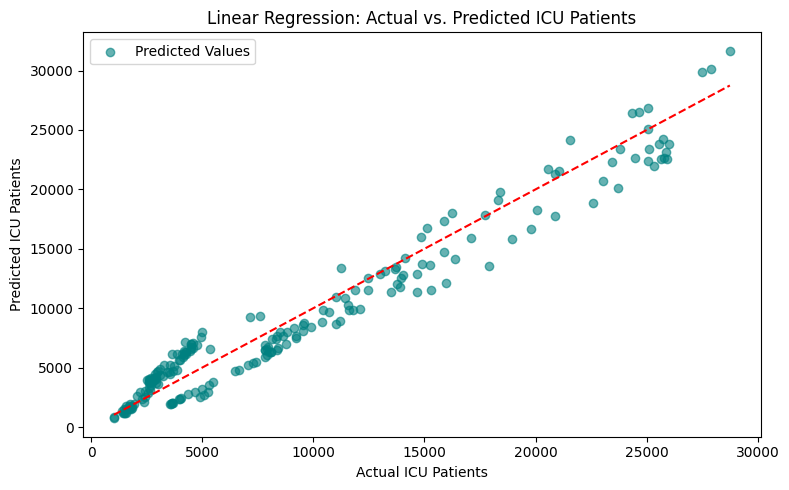

In [14]:
plt.figure(figsize=(8, 5))

# Scatter plot: model predictions
plt.scatter(yr_test, y_pred_linreg, alpha=0.6, color='teal', label='Predicted Values')

# Reference line: perfect predictions
plt.plot([yr_test.min(), yr_test.max()], [yr_test.min(), yr_test.max()], 'r--')
plt.xlabel("Actual ICU Patients")
plt.ylabel("Predicted ICU Patients")
plt.title("Linear Regression: Actual vs. Predicted ICU Patients")
plt.legend()  # <-- adds the label box
plt.tight_layout()
plt.show()


### Using Random Forest Regressor for Comparison

In [15]:
# Training the Model
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg.fit(Xr_train, yr_train)

# Predict
y_pred_rf = rf_reg.predict(Xr_test)

# Metrics
mse_rf = mean_squared_error(yr_test, y_pred_rf)
r2_rf = r2_score(yr_test, y_pred_rf)

print("Random Forest MSE:", round(mse_rf, 2))
print("Random Forest R²:", round(r2_rf, 4))

Random Forest MSE: 427994.44
Random Forest R²: 0.9926


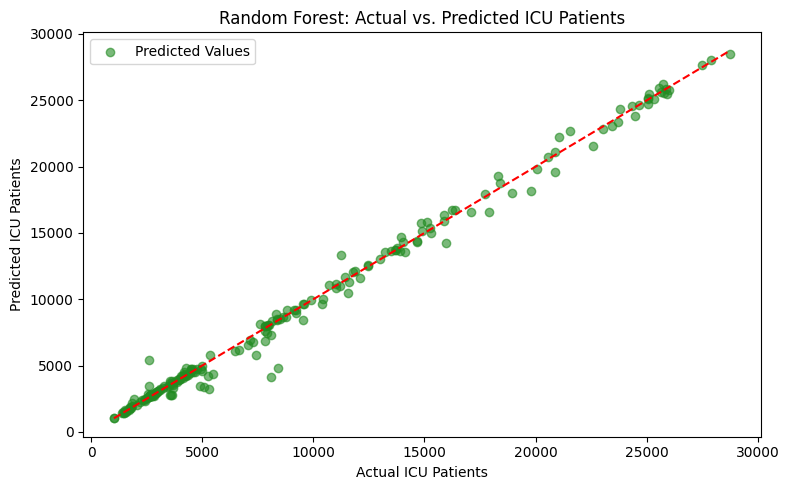

In [16]:
plt.figure(figsize=(8, 5))
plt.scatter(yr_test, y_pred_rf, alpha=0.6, color='forestgreen', label='Predicted Values')
plt.plot([yr_test.min(), yr_test.max()], [yr_test.min(), yr_test.max()], 'r--')
plt.xlabel("Actual ICU Patients")
plt.ylabel("Predicted ICU Patients")
plt.title("Random Forest: Actual vs. Predicted ICU Patients")
plt.legend()
plt.tight_layout()
plt.show()
